**Prophet**:
- Prophet is a procedure for forecasting time series data based on an additive model where non-linear trends are fit with yearly, weekly, and daily seasonality, plus holiday effects. It works best with time series that have strong seasonal effects and several seasons of historical data. Prophet is robust to missing data and shifts in the trend, and typically handles outliers well.
- Maybe don't need one that handles missing data if we don't have any

# Inputs

In [2]:
# Minimum viable dataframe -> two mandatory columns minimum

#Our data should already contain the datetime as index and all features as columns
# Data should be scaled.. Prophet handels target scaling and missings

#Target as extra input also with datetime index

import pandas as pd

df = pd.read_csv('preprocessed_data.csv')


# ds must be a proper datetime, not a string
df.datetime_utc12 = pd.to_datetime(df.datetime_utc12)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52585 entries, 0 to 52584
Data columns (total 81 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   datetime_utc12                        52585 non-null  datetime64[ns]
 1   el_price_dol_MWh_BEN2201              52585 non-null  float64       
 2   el_price_dol_MWh_HAY2201              52585 non-null  float64       
 3   el_price_dol_MWh_INV2201              52585 non-null  float64       
 4   el_price_dol_MWh_ISL2201              52585 non-null  float64       
 5   el_price_dol_MWh_KIK2201              52585 non-null  float64       
 6   el_price_dol_MWh_OTA2201              52585 non-null  float64       
 7   el_price_dol_MWh_RDF2201              52585 non-null  float64       
 8   el_price_dol_MWh_SFD2201              52585 non-null  float64       
 9   el_price_dol_MWh_WKM2201              52585 non-null  float64       
 10

# Lastmile Preprocesssing

In [3]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Step 1: Rename for Prophet
df_prophet = df[['datetime_utc12', 'el_price_dol_MWh_OTA2201']].rename(
    columns={'datetime_utc12': 'ds', 'el_price_dol_MWh_OTA2201': 'y'}
)

# Step 2: Get feature columns (exclude ds, y, and Direction)
feature_cols = [c for c in df.columns if c not in
                ['datetime_utc12', 'el_price_dol_MWh_OTA2201', 'Direction']]

# Step 3: Scale features
scaler = MinMaxScaler()
df_prophet[feature_cols] = scaler.fit_transform(df[feature_cols])

# Step 4: Bring Direction back in unscaled
df_prophet['Direction'] = df['Direction'].values

In [32]:
df_prophet.head()

,ds,y,el_price_dol_MWh_BEN2201,el_price_dol_MWh_HAY2201,el_price_dol_MWh_INV2201,el_price_dol_MWh_ISL2201,el_price_dol_MWh_KIK2201,el_price_dol_MWh_RDF2201,el_price_dol_MWh_SFD2201,el_price_dol_MWh_WKM2201,...,demand_GWh_UNI,demand_GWh_USI,avg_flow_MW,peak_flow_MW,outage_Gas_MW,outage_Hyd_MW,outage_Ter_MW,outage_Win_MW,outage_UNKN_MW,Direction
0,2019-01-01 00:00:00,176.515,0.045939,0.042556,0.050035,0.044608,0.042505,0.032626,0.042770,0.041452,...,0.379325,0.467257,0.489097,0.494426,0.096967,0.001636,0.439148,0.085039,0.083333,1.0
1,2019-01-01 01:00:00,162.070,0.042250,0.039114,0.046061,0.041021,0.039078,0.029982,0.039270,0.038093,...,0.370571,0.427434,0.484565,0.486065,0.096967,0.001636,0.439148,0.085039,0.083333,1.0
2,2019-01-01 02:00:00,144.645,0.037741,0.034934,0.041129,0.036576,0.034845,0.026759,0.035068,0.033998,...,0.355565,0.404425,0.482583,0.483278,0.096967,0.001636,0.439148,0.085039,0.083333,1.0
3,2019-01-01 03:00:00,133.355,0.034821,0.032204,0.038035,0.033662,0.032069,0.024667,0.032327,0.031339,...,0.347228,0.394690,0.482866,0.485507,0.096967,0.001636,0.439148,0.085039,0.083333,1.0
4,2019-01-01 04:00:00,139.955,0.036448,0.033730,0.040032,0.035264,0.033604,0.025902,0.033926,0.032908,...,0.348062,0.407080,0.493911,0.498328,0.096967,0.001636,0.439148,0.085039,0.083333,1.0


In [13]:
print(df_prophet.isnull().sum()[df_prophet.isnull().sum() > 0])
print(f"\nTotal NaNs: {df_prophet.isnull().sum().sum()}")
pd.set_option('display.max_rows', None)
print(df_prophet.isnull().sum()[df_prophet.isnull().sum() > 0])

Coal              18
Diesel            18
Ele               18
Gas               18
Geo               18
                  ..
outage_Hyd_MW      6
outage_Ter_MW      6
outage_Win_MW      6
outage_UNKN_MW     6
Direction          6
Length: 66, dtype: int64

Total NaNs: 504
Coal                                    18
Diesel                                  18
Ele                                     18
Gas                                     18
Geo                                     18
Hydro                                   18
Solar                                   18
Wind                                    18
Wood                                    18
palmerston_north_wind_kmh                6
palmerston_north_wind_dir_deg            6
wellington_wind_kmh                      6
wellington_wind_dir_deg                  6
harapaki_hawkesbay_wind_kmh              6
harapaki_hawkesbay_wind_dir_deg          6
te_uku_waikato_wind_kmh                  6
te_uku_waikato_wind_dir_deg            

In [4]:
df_prophet.fillna(method='ffill', inplace=True)

/var/folders/yw/lmg35gj91jz169bt0mk7qhrw0000gp/T/ipykernel_50189/1696363551.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_prophet.fillna(method='ffill', inplace=True)


In [5]:
# lag all other node prices by 24h (production is still leakage)

price_cols = [c for c in df_prophet.columns if 'el_price' in c and c != 'y']

for col in price_cols:
    df_prophet[col] = df_prophet[col].shift(24)

df_prophet.dropna(inplace=True)

In [35]:
df_prophet.head()

,ds,y,el_price_dol_MWh_BEN2201,el_price_dol_MWh_HAY2201,el_price_dol_MWh_INV2201,el_price_dol_MWh_ISL2201,el_price_dol_MWh_KIK2201,el_price_dol_MWh_RDF2201,el_price_dol_MWh_SFD2201,el_price_dol_MWh_WKM2201,...,demand_GWh_UNI,demand_GWh_USI,avg_flow_MW,peak_flow_MW,outage_Gas_MW,outage_Hyd_MW,outage_Ter_MW,outage_Win_MW,outage_UNKN_MW,Direction
24,2019-01-02 00:00:00,76.910,0.045939,0.042556,0.050035,0.044608,0.042505,0.032626,0.042770,0.041452,...,0.360150,0.443363,0.418012,0.438127,0.096967,0.001636,0.439148,0.085039,0.083333,1.0
25,2019-01-02 01:00:00,86.615,0.042250,0.039114,0.046061,0.041021,0.039078,0.029982,0.039270,0.038093,...,0.345144,0.408850,0.388558,0.380156,0.096967,0.001636,0.439148,0.085039,0.083333,-1.0
26,2019-01-02 02:00:00,82.165,0.037741,0.034934,0.041129,0.036576,0.034845,0.026759,0.035068,0.033998,...,0.339725,0.393805,0.398187,0.399108,0.096967,0.001636,0.439148,0.085039,0.083333,-1.0
27,2019-01-02 03:00:00,98.775,0.034821,0.032204,0.038035,0.033662,0.032069,0.024667,0.032327,0.031339,...,0.337641,0.391150,0.398187,0.399108,0.096967,0.001636,0.439148,0.085039,0.083333,-1.0
28,2019-01-02 04:00:00,98.355,0.036448,0.033730,0.040032,0.035264,0.033604,0.025902,0.033926,0.032908,...,0.343060,0.409735,0.398187,0.399108,0.096967,0.001636,0.439148,0.085039,0.083333,-1.0


# Dummy inputs

In [4]:
import pandas as pd
import numpy as np

periods = 24 * 365 * 5
ds = pd.date_range('2019-01-01', periods=periods, freq='h')
np.random.seed(42)

hour_effect = 20 * np.sin(2 * np.pi * ds.hour / 24)
day_effect  = 10 * np.sin(2 * np.pi * ds.dayofweek / 7)
trend       = np.linspace(50, 80, periods)
noise       = np.random.normal(0, 5, periods)

df = pd.DataFrame({
    'ds':                    ds,
    'y':                     trend + hour_effect + day_effect + noise,
    'demand_north':          1000 + 200 * np.sin(2 * np.pi * ds.hour / 24) + np.random.normal(0, 20, periods),
    'wind_generation':       300 + 150 * np.random.rand(periods),
    'hydro_storage':         4000 + 500 * np.sin(2 * np.pi * ds.dayofyear / 365) + np.random.normal(0, 50, periods),
    'temperature_auckland':  15 + 8 * np.sin(2 * np.pi * (ds.dayofyear - 15) / 365) + np.random.normal(0, 2, periods),
})
df.head()

,ds,y,demand_north,wind_generation,hydro_storage,temperature_auckland
0,2019-01-01 00:00:00,60.301886,1022.721324,319.974065,3871.757935,11.111119
1,2019-01-01 01:00:00,62.304059,1064.791922,351.705925,3989.218049,10.748063
2,2019-01-01 02:00:00,71.058127,1091.585196,393.946170,3981.493013,12.952032
3,2019-01-01 03:00:00,79.577655,1157.477934,300.700810,4025.567874,14.605369
4,2019-01-01 04:00:00,73.970796,1214.843242,429.794213,4060.059202,13.619390


# Setup

In [6]:
# Install if needed: pip install prophet
from prophet import Prophet

m = Prophet(
    seasonality_mode='multiplicative',   # or 'additive', but for volatile peaks multiplicative should work best
    daily_seasonality=True,         # we'll add custom below
    weekly_seasonality=True,
    yearly_seasonality=True,
)


/Users/Dave/.pyenv/versions/3.10.6/envs/Duckstradamus/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


# Hourly and Seasonality

In [7]:


# Add hourly cycle (24h period)
m.add_seasonality(
    name='hourly',
    period=1,           # 1 day = 24 periods for hourly data
    fourier_order=8,    # start at 8, tune later. Fourier order = how many sine/cosine waves to use.
)

# Also consider a weekly-hour interaction
m.add_seasonality(
    name='weekly_hourly',
    period=7,
    fourier_order=5,
)

# Annual cycle - critical for NZ hydro-dependent pricing
m.add_seasonality(
    name='yearly',
    period=365.25,
    fourier_order=10,
)

#regressors tell Prophet which columns are used as feature. this loop adds all columns as feature
exclude = ['ds', 'y']  # CHANGE TO ACTUAL NAMES OF DATETIME AND WHOLESALEPIRCE-TARGET COLUMN
regressors = [col for col in df_prophet.columns if col not in exclude]

for col in regressors:
    m.add_regressor(col)


# Fit

In [8]:
m.fit(df_prophet)

16:11:12 - cmdstanpy - INFO - Chain [1] start processing
16:13:26 - cmdstanpy - INFO - Chain [1] done processing


# Cross validate

In [ ]:
from prophet.diagnostics import cross_validation, performance_metrics

# test with just 3 folds to gauge speed
df_cv_test = cross_validation(
    m,
    initial='1095 days',
    period='30 days',  # ~27 folds only
    horizon='1 days',
    parallel='processes'
)


Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
22:30:09 - cmdstanpy - INFO - Chain [1] start processing
22:30:11 - cmdstanpy - INFO - Chain [1] start processing
22:30:13 - cmdstanpy - INFO - Chain [1] start processing
22:30:14 - cmdstanpy - INFO - Chain [1] start processing
22:30:16 - cmdstanpy - INFO - Chain [1] start processing
22:30:21 - cmdstanpy - INFO - Chain [1] start processing
22:30:23 - cmdstanpy - INFO - Chain [1] start processing
22:30:27 - cmdstanpy - INFO - Chain [1] start processing
22:35:13 - cmdstanpy - INFO - Chain [1] done processing
22:35:54 - cmdstanpy - I

NameError: name 'df_cv' is not defined

In [42]:
#get and print performance matrix
metrics = performance_metrics(df_cv_test)
print(metrics[['horizon', 'mae', 'rmse', 'mape']])

           horizon        mae       rmse        mape
0  0 days 03:00:00  42.418297  57.212119  500.772946
1  0 days 04:00:00  40.298977  50.721244  484.099451
2  0 days 05:00:00  37.711722  46.864979  316.324708
3  0 days 06:00:00  37.286239  47.688350  138.041535
4  0 days 07:00:00  39.660912  49.284327   74.493841
5  0 days 08:00:00  44.644984  61.219166   38.508220
6  0 days 09:00:00  44.534269  60.865557   84.855459
7  0 days 10:00:00  47.165725  64.176938  131.275882
8  0 days 11:00:00  49.123584  68.490174  135.605958
9  0 days 12:00:00  48.768693  64.831543  170.635218
10 0 days 13:00:00  47.845174  56.945865  237.669434
11 0 days 14:00:00  49.576321  58.551155  271.887116
12 0 days 15:00:00  48.963757  64.111731  257.409487
13 0 days 16:00:00  45.117629  64.415850  167.978958
14 0 days 17:00:00  43.128327  63.039330   64.746989
15 0 days 18:00:00  47.589650  76.293761   11.341410
16 0 days 19:00:00  50.031404  81.404717    1.042449
17 0 days 20:00:00  48.828800  76.734446    0.

/Users/Dave/.pyenv/versions/3.10.6/envs/Duckstradamus/lib/python3.10/site-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/Users/Dave/.pyenv/versions/3.10.6/envs/Duckstradamus/lib/python3.10/site-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


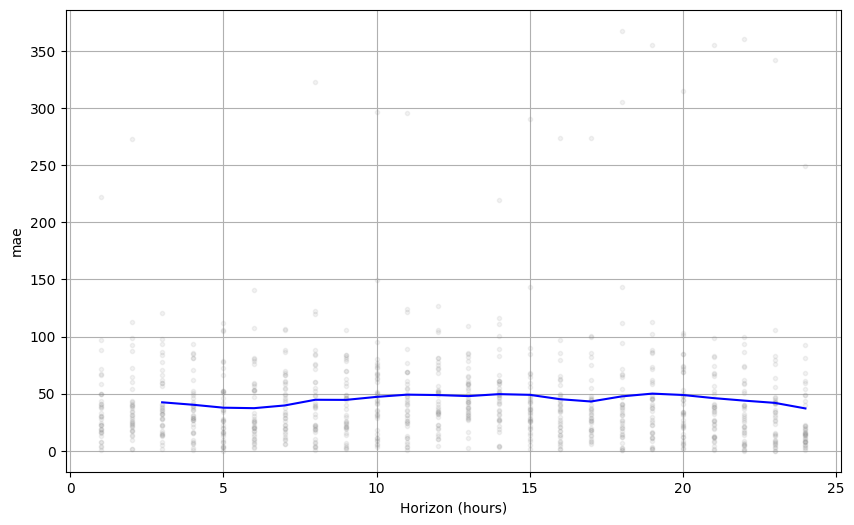

/Users/Dave/.pyenv/versions/3.10.6/envs/Duckstradamus/lib/python3.10/site-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/Users/Dave/.pyenv/versions/3.10.6/envs/Duckstradamus/lib/python3.10/site-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


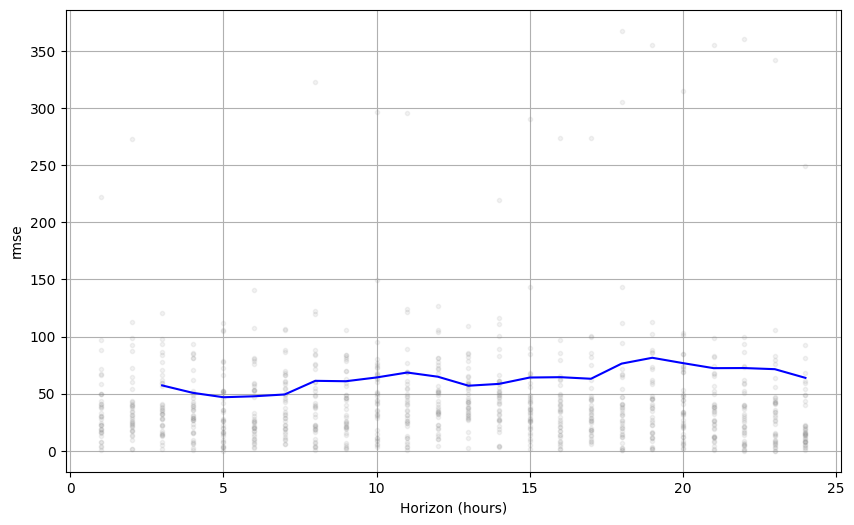

In [46]:
#plot error

from prophet.plot import plot_cross_validation_metric
import matplotlib.pyplot as plt

fig1 = plot_cross_validation_metric(df_cv_test, metric='mae')
plt.show()
plt.close(fig1)

fig2 = plot_cross_validation_metric(df_cv_test, metric='rmse')
plt.show()
plt.close(fig2)


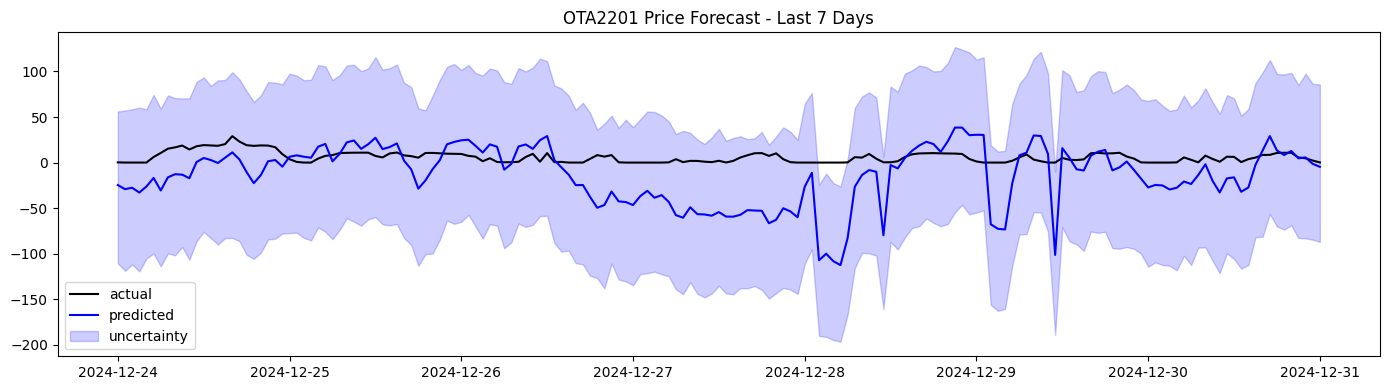

In [47]:
# Step 1: predict on known data
future = df_prophet.drop(columns='y')
forecast = m.predict(future)

# Step 2: plot - last 7 days actual vs predicted
cutoff = df_prophet['ds'].max() - pd.Timedelta(days=7)
mask_actual = df_prophet['ds'] >= cutoff
mask_forecast = forecast['ds'] >= cutoff

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_prophet.loc[mask_actual, 'ds'],
        df_prophet.loc[mask_actual, 'y'],
        label='actual', color='black')
ax.plot(forecast.loc[mask_forecast, 'ds'],
        forecast.loc[mask_forecast, 'yhat'],
        label='predicted', color='blue')
ax.fill_between(forecast.loc[mask_forecast, 'ds'],
                forecast.loc[mask_forecast, 'yhat_lower'],
                forecast.loc[mask_forecast, 'yhat_upper'],
                alpha=0.2, color='blue', label='uncertainty')
ax.legend()
ax.set_title('OTA2201 Price Forecast - Last 7 Days')
plt.tight_layout()
plt.show()

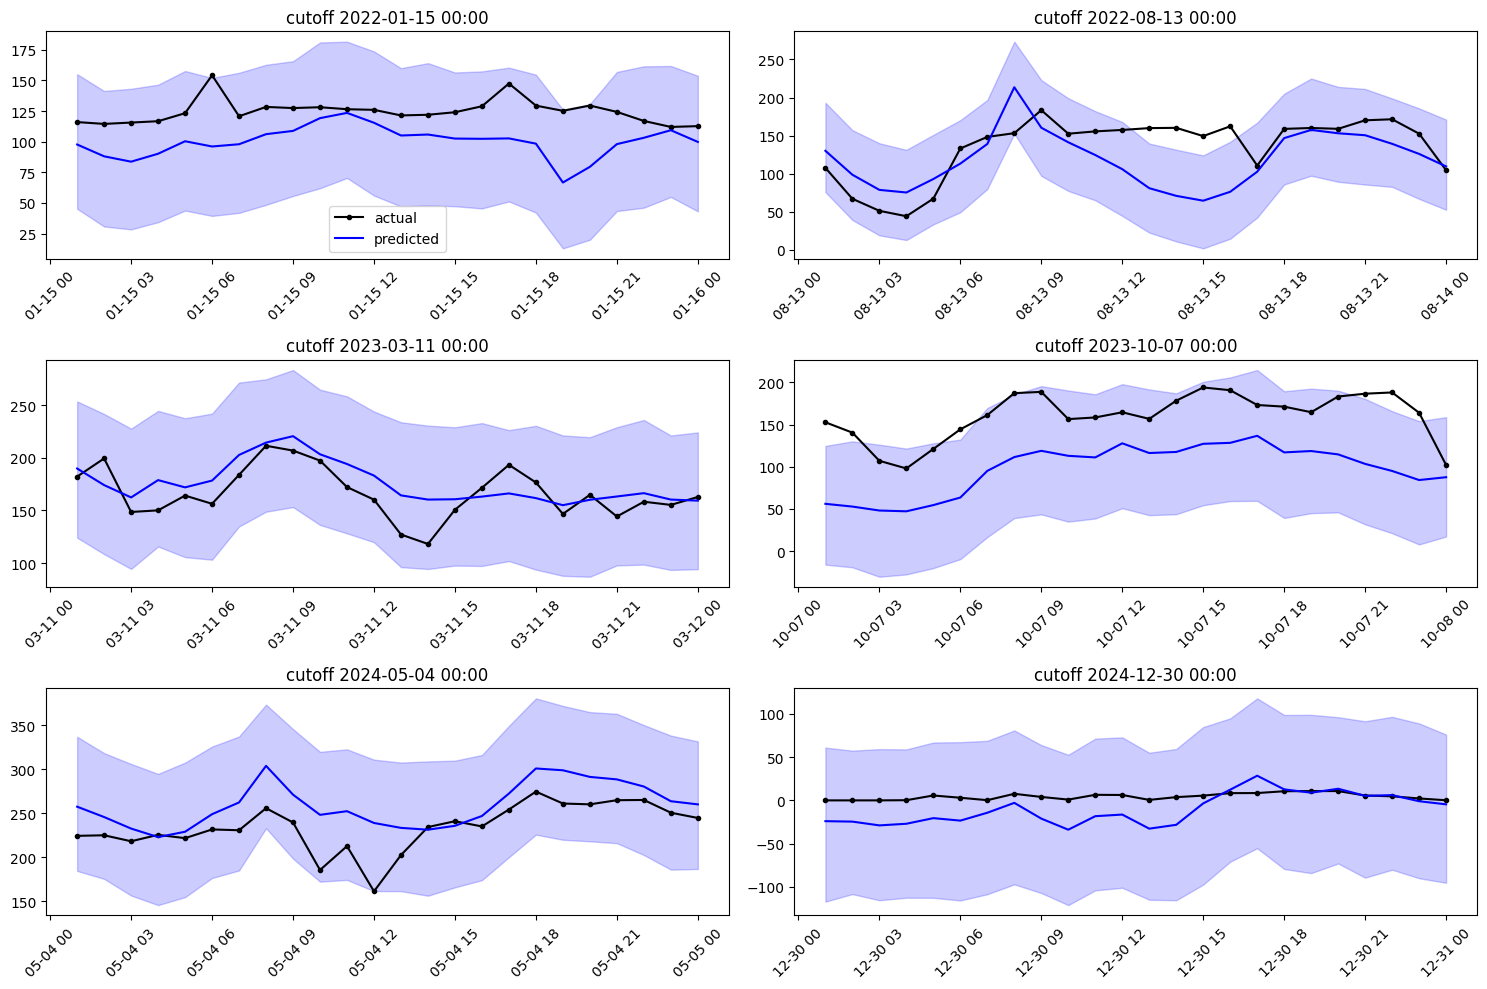

In [51]:

# 2. Plot a handful of individual folds: predicted vs actual over their 24h window
cutoffs = sorted(df_cv_test['cutoff'].unique())

# pick 6 folds spread across the test period (not just the first 6)
import numpy as np
picks = np.linspace(0, len(cutoffs) - 1, 6, dtype=int)
sel = [cutoffs[i] for i in picks]

fig, axes = plt.subplots(3, 2, figsize=(15, 10), sharey=False)
for ax, co in zip(axes.ravel(), sel):
    fold = df_cv_test[df_cv_test['cutoff'] == co].sort_values('ds')
    ax.plot(fold['ds'], fold['y'],    label='actual',    color='black', marker='.')
    ax.plot(fold['ds'], fold['yhat'], label='predicted', color='blue')
    ax.fill_between(fold['ds'], fold['yhat_lower'], fold['yhat_upper'],
                    alpha=0.2, color='blue')
    ax.set_title(f"cutoff {pd.Timestamp(co):%Y-%m-%d %H:%M}")
    ax.tick_params(axis='x', rotation=45)
axes.ravel()[0].legend()
plt.tight_layout()
plt.show()

count     37.000000
mean      44.078619
std       33.184878
min       12.233400
25%       29.299511
50%       37.834729
75%       50.450332
max      218.487402
Name: fold_MAE, dtype: float64


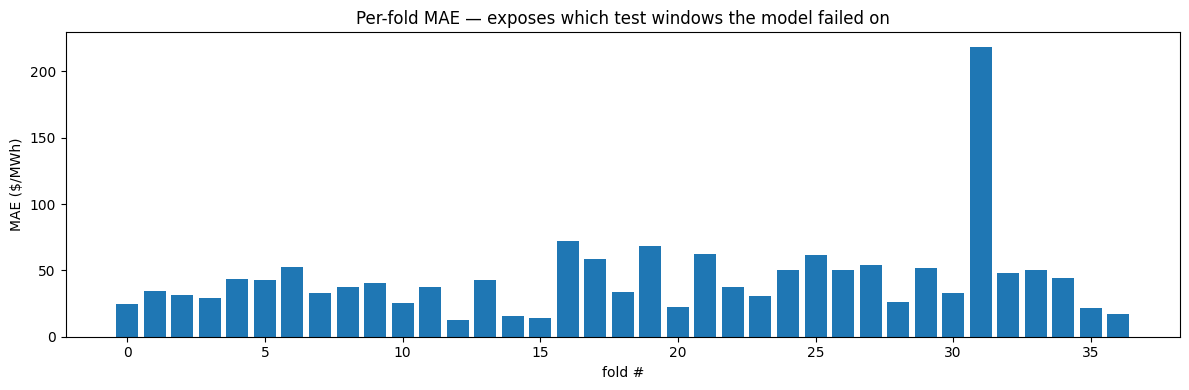

In [52]:
# 3. Per-fold error, so you can see the variance the aggregate metrics hide
fold_err = (df_cv_test
            .assign(abs_err=lambda d: (d['y'] - d['yhat']).abs())
            .groupby('cutoff')['abs_err']
            .mean()
            .reset_index(name='fold_MAE'))

print(fold_err['fold_MAE'].describe())

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(fold_err)), fold_err['fold_MAE'])
ax.set_xlabel('fold #'); ax.set_ylabel('MAE ($/MWh)')
ax.set_title('Per-fold MAE — exposes which test windows the model failed on')
plt.tight_layout()
plt.show()

In [53]:
from prophet.utilities import regressor_coefficients

coefs = regressor_coefficients(m)
coefs = coefs.reindex(coefs['coef'].abs().sort_values(ascending=False).index)
print(coefs.to_string())

                               regressor  regressor_mode    center  coef_lower       coef  coef_upper
4               el_price_dol_MWh_KIK2201  multiplicative  0.033113  -31.836924 -31.836924  -31.836924
0               el_price_dol_MWh_BEN2201  multiplicative  0.034893   28.244989  28.244989   28.244989
7               el_price_dol_MWh_WKM2201  multiplicative  0.033720    8.775006   8.775006    8.775006
2               el_price_dol_MWh_INV2201  multiplicative  0.036334    4.518803   4.518803    4.518803
6               el_price_dol_MWh_SFD2201  multiplicative  0.033837   -4.508788  -4.508788   -4.508788
3               el_price_dol_MWh_ISL2201  multiplicative  0.034041    2.666812   2.666812    2.666812
9                                 Diesel  multiplicative  0.005761    2.618604   2.618604    2.618604
1               el_price_dol_MWh_HAY2201  multiplicative  0.033550   -1.705126  -1.705126   -1.705126
69                        demand_GWh_UNI  multiplicative  0.562272    1.443085   1

In [9]:
import numpy as np

# In-sample: predict on the training data itself
insample = m.predict(df_prophet.drop(columns='y'))
train_mae  = np.mean(np.abs(df_prophet['y'].values - insample['yhat'].values))
train_rmse = np.sqrt(np.mean((df_prophet['y'].values - insample['yhat'].values)**2))

# Out-of-sample: from the CV you already have
cv_mae  = np.mean(np.abs(df_cv_test['y'] - df_cv_test['yhat']))
cv_rmse = np.sqrt(np.mean((df_cv_test['y'] - df_cv_test['yhat'])**2))

print(f"Train MAE:  {train_mae:6.2f}   |  CV MAE:  {cv_mae:6.2f}")
print(f"Train RMSE: {train_rmse:6.2f}   |  CV RMSE: {cv_rmse:6.2f}")
print(f"Gap (CV/Train MAE ratio): {cv_mae/train_mae:.2f}x")

NameError: name 'df_cv_test' is not defined

# Predict

In [21]:
# We might split it beforehand so we have 24 hours of feature to use to predict the price

# Build a future dataframe for next 24 hours
future = m.make_future_dataframe(
    periods=24,
    freq='h',
    include_history=False   # just the forecast window
)

# Attach regressor forecasts for those 24 hours
future['demand_north']      = demand_forecast_24h
future['wind_generation']    = wind_forecast_24h
future['hydro_storage']     = hydro_now   # relatively static
future['temperature_auckland'] = temp_forecast_24h

forecast = m.predict(future)

# Key output columns:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

NameError: name 'demand_forecast_24h' is not defined